In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\abhir\Downloads\Train.csv")
df.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [54]:
df.shape

(8523, 12)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [56]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [59]:
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)


C:\Users\abhir\AppData\Local\Temp\ipykernel_14640\2636400358.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
C:\Users\abhir\AppData\Local\Temp\ipykernel_14640\2636400358.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

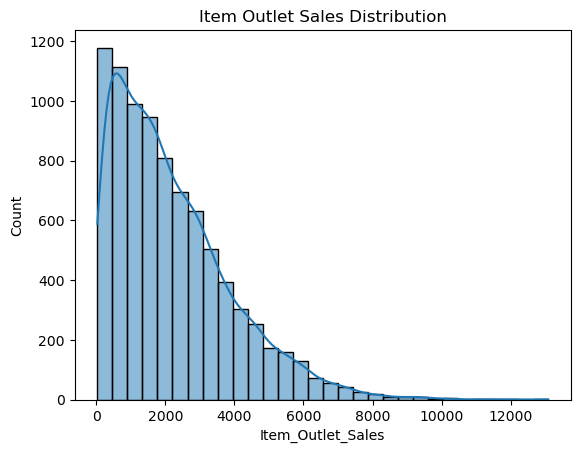

Mean Sales: 2181.288913575032
Max Sales: 13086.9648
Min Sales: 33.29


In [60]:
sns.histplot(df['Item_Outlet_Sales'] , bins=30 , kde=True)
plt.title('Item Outlet Sales Distribution')
plt.show()

print('Mean Sales:', df['Item_Outlet_Sales'].mean())
print('Max Sales:', df['Item_Outlet_Sales'].max())
print('Min Sales:', df['Item_Outlet_Sales'].min())

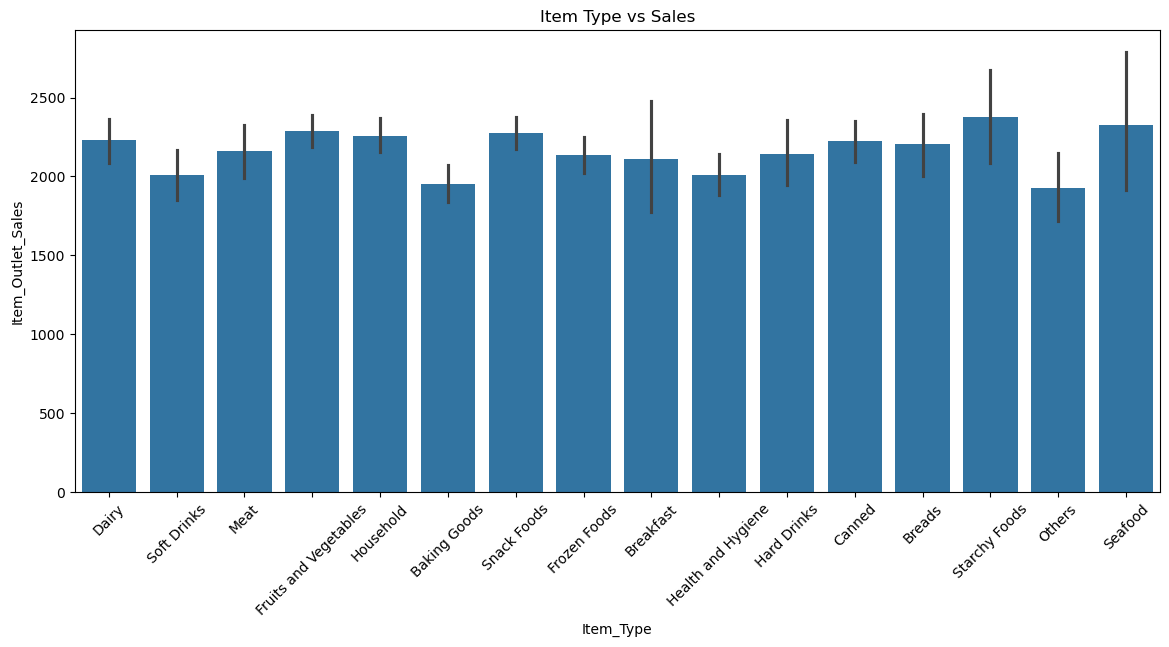

In [61]:
plt.figure(figsize=(14,6))
sns.barplot(x='Item_Type' , y='Item_Outlet_Sales' , data=df)
plt.title('Item Type vs Sales')
plt.xticks(rotation=45)
plt.show()


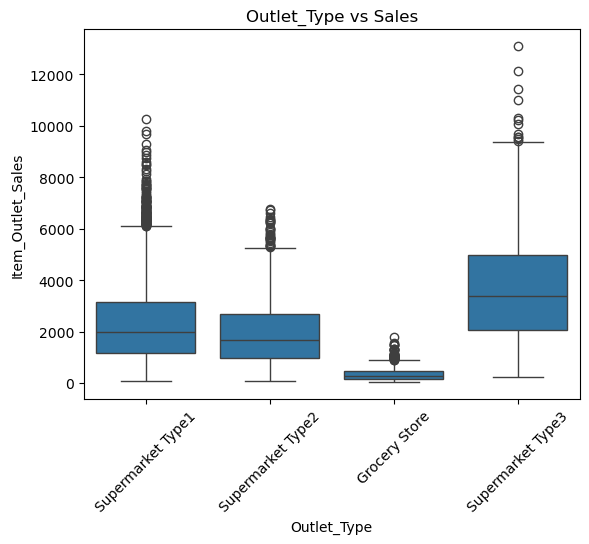

In [62]:
sns.boxplot(x='Outlet_Type' , y='Item_Outlet_Sales' , data=df)
plt.title('Outlet_Type vs Sales')
plt.xticks(rotation=45)
plt.show()

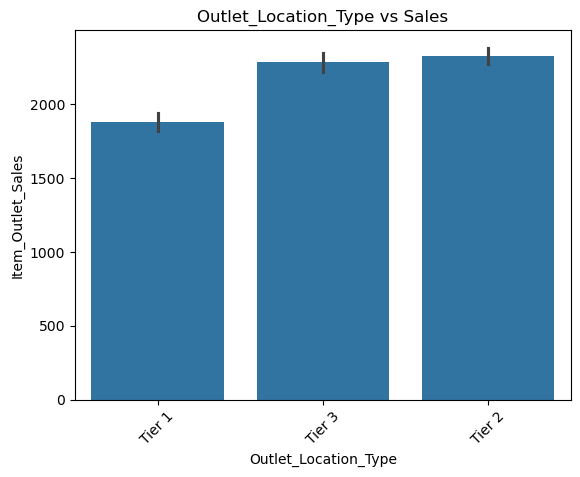

In [63]:
sns.barplot(x='Outlet_Location_Type' , y='Item_Outlet_Sales' , data=df)
plt.title('Outlet_Location_Type vs Sales')
plt.xticks(rotation=45)
plt.show()

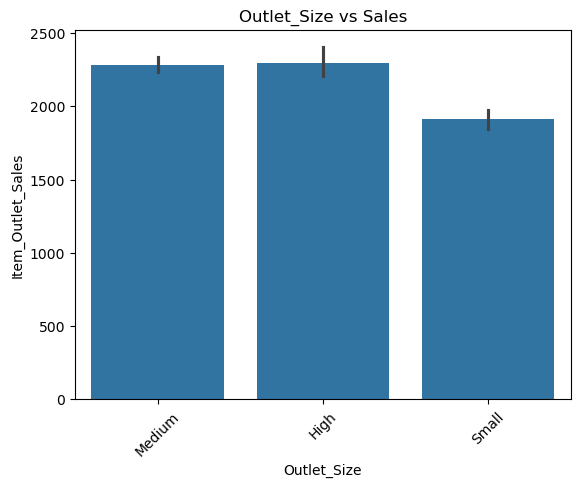

In [64]:
sns.barplot(x='Outlet_Size' , y='Item_Outlet_Sales' , data=df)
plt.title('Outlet_Size vs Sales')
plt.xticks(rotation=45)
plt.show()

In [65]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [66]:
df['Item_Fat_Content'] =df['Item_Fat_Content'].replace({
    'low fat' : 'Low Fat',
    'LF' : 'Low Fat',
    'reg' : 'Regular'
})
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

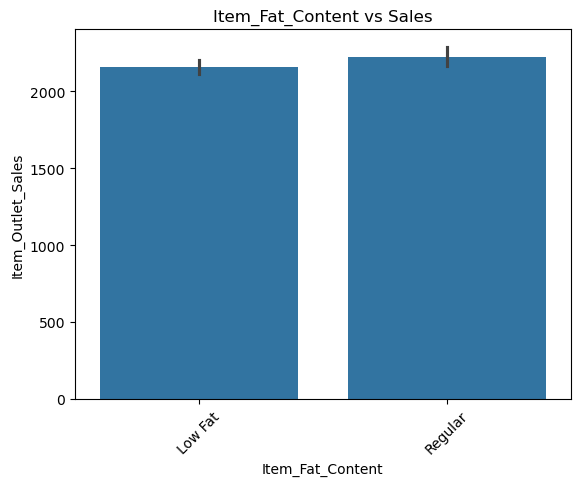

In [67]:
sns.barplot(x='Item_Fat_Content' , y='Item_Outlet_Sales' , data=df)
plt.title('Item_Fat_Content vs Sales')
plt.xticks(rotation=45)
plt.show()

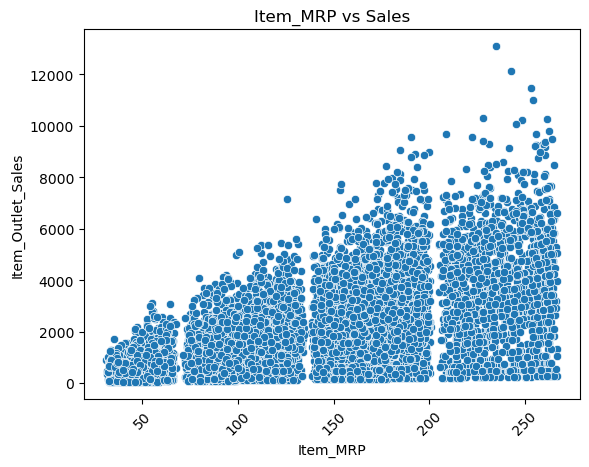

In [68]:
sns.scatterplot(x='Item_MRP' ,  y='Item_Outlet_Sales' , data=df)
plt.title('Item_MRP vs Sales')
plt.xticks(rotation=45)
plt.show()

<Axes: >

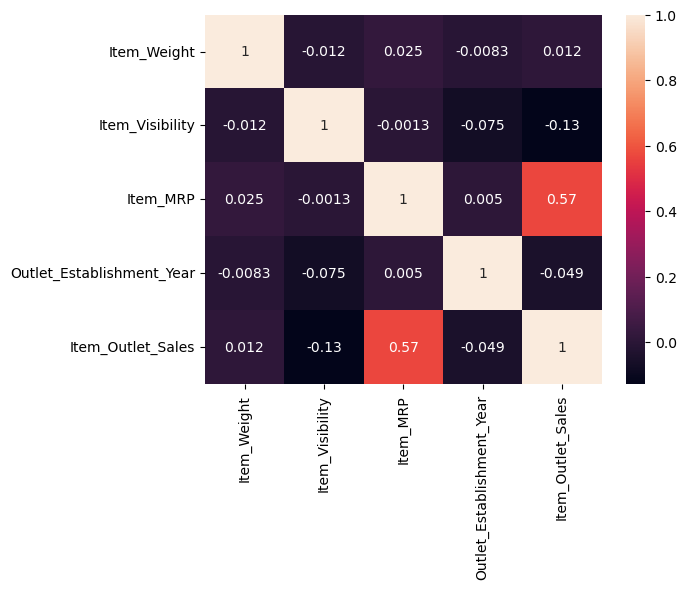

In [69]:
sns.heatmap(df.corr(numeric_only=True) , annot=True)

# Feature selection 

In [70]:
df.drop(columns=['Item_Identifier' , 'Outlet_Identifier'],inplace=True)

In [71]:
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,Medium,Tier 3,Grocery Store,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052


In [72]:
df.shape

(8523, 10)

# Feature encoding

In [73]:
df = pd.get_dummies(df , drop_first=True)
df = df.astype(int)

In [74]:
df

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9,0,249,1999,3735,0,0,0,0,1,...,0,0,0,1,0,0,0,1,0,0
1,5,0,48,2009,443,1,0,0,0,0,...,0,1,0,1,0,0,1,0,1,0
2,17,0,141,1999,2097,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,19,0,182,1998,732,1,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
4,8,0,53,1987,994,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6,0,214,1987,2778,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
8519,8,0,108,2002,549,1,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0
8520,10,0,85,2004,1193,0,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
8521,7,0,103,2009,1845,1,0,0,0,0,...,1,0,0,1,0,0,1,0,1,0


In [75]:
X = df.drop(columns=['Item_Outlet_Sales'],axis=1)
y = df['Item_Outlet_Sales']
print('x shape:', X.shape)
print('y shape:', y.shape)

x shape: (8523, 27)
y shape: (8523,)


# Train Test split 

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print('x_train:', x_train.shape)
print('x_test:', x_test.shape)

x_train: (6818, 27)
x_test: (1705, 27)


# Feature scaling 

In [78]:
from sklearn.preprocessing import StandardScaler

In [79]:
stand = StandardScaler()
X_train = stand.fit_transform(x_train)
X_test = stand.fit_transform(x_test)

# Model 1 Linear Regression

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score , r2_score , mean_absolute_error ,mean_squared_error

In [81]:
Lr = LinearRegression()
Lr.fit(X_train , y_train)
y_pred_lr = Lr.predict(X_test)


print('=== Linear Regression ===')
print('R2 Score:', r2_score(y_test, y_pred_lr))
print('MAE     :', mean_absolute_error(y_test, y_pred_lr))
print('RMSE    :', np.sqrt(mean_squared_error(y_test, y_pred_lr)))

=== Linear Regression ===
R2 Score: 0.5750379067620338
MAE     : 803.7591368267591
RMSE    : 1074.7251072214738


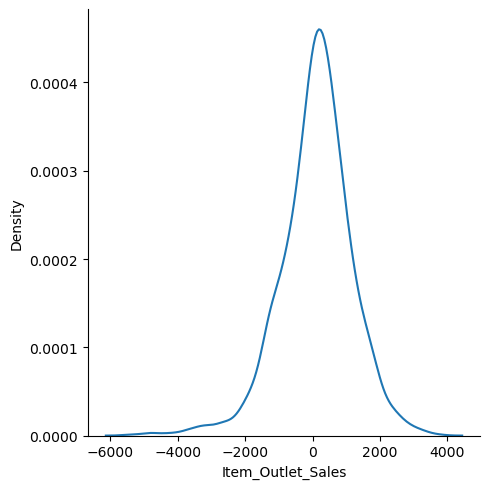

In [82]:
sns.displot(y_pred_lr-y_test , kind='kde')

# Model 2 Random Forest

In [83]:
from sklearn.ensemble import RandomForestRegressor

In [84]:
rf = RandomForestRegressor(n_estimators=100 , random_state=42)
rf.fit(x_train , y_train)
y_pred_rf = rf.predict(x_test)

In [85]:
print('=== RandomForest Regressor ===')
print('R2 Score:', r2_score(y_test, y_pred_rf))
print('MAE     :', mean_absolute_error(y_test, y_pred_rf))
print('RMSE    :', np.sqrt(mean_squared_error(y_test, y_pred_rf)))

=== RandomForest Regressor ===
R2 Score: 0.5402359788798354
MAE     : 776.1848300237397
RMSE    : 1117.866109401924


# Model 3 Ridge 

In [86]:
from sklearn.linear_model import Ridge , Lasso
from sklearn.model_selection import GridSearchCV

In [87]:
ridge = Ridge(alpha=5)
ridge.fit(X_train , y_train)

Ridge(alpha=5)

In [88]:
parameter = {'alpha' : [1,2,5,10,20,30,50,60,70,80,90]}
ridge_cv = GridSearchCV(ridge ,parameter , cv=5)
ridge_cv.fit(X_train , y_train)

GridSearchCV(cv=5, estimator=Ridge(alpha=5),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 50, 60, 70, 80, 90]})

In [89]:
ridge_cv.best_params_

{'alpha': 5}

In [90]:
y_pred_ridge = ridge.predict(X_test)
y_pred_ridge

array([1393.29823462,  814.80512286,  860.12836842, ...,  881.46668226,
        676.10141119, 1797.26062358])

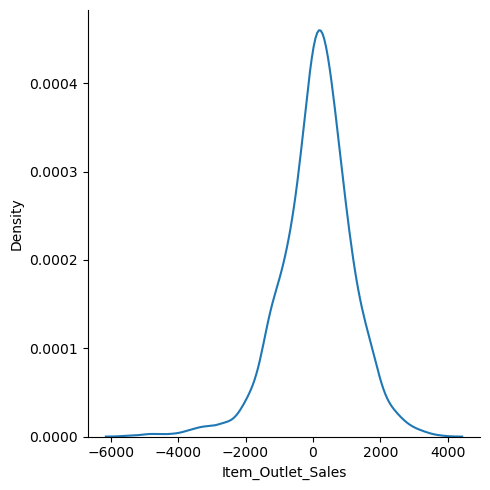

In [91]:
sns.displot(y_pred_ridge-y_test , kind='kde')

In [92]:
print('=== Ridge ===')
print('R2 :', r2_score(y_test, y_pred_ridge))
print('MAE:', mean_absolute_error(y_test, y_pred_ridge))


=== Ridge ===
R2 : 0.5749798295519415
MAE: 803.6576951127458


# Model 4 lasso

In [93]:
lasso = Lasso()
lasso.fit(X_train , y_train)

Lasso()

In [94]:
y_pred_lasso = lasso.predict(X_test)
print('=== Lasso ===')
print('R2 :', r2_score(y_test, y_pred_lasso))
print('MAE:', mean_absolute_error(y_test, y_pred_lasso))


=== Lasso ===
R2 : 0.5743755854047667
MAE: 803.8203072023761


# Model 5 Desision Tree

In [95]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

In [96]:
tree = DecisionTreeRegressor()
tree.fit(x_train , y_train)

DecisionTreeRegressor()

In [97]:
y_pred_tree = tree.predict(x_test)
print('=== Decision tree  ===')
print('R2 :', r2_score(y_test, y_pred_tree))
print('MAE:', mean_absolute_error(y_test, y_pred_tree))


=== Decision tree  ===
R2 : 0.17783195532843643
MAE: 1028.9547409579668


# Model 6 KNN

In [98]:
KNN = KNeighborsRegressor()
KNN.fit(X_train , y_train)

KNeighborsRegressor()

In [99]:
y_pred_KNN = KNN.predict(X_test)
print('=== KNN  ===')
print('R2 :', r2_score(y_test, y_pred_KNN))
print('MAE:', mean_absolute_error(y_test, y_pred_KNN))


=== KNN  ===
R2 : 0.5104648265981159
MAE: 823.7630498533724


# Model 7 GradentBoosting

In [100]:
from sklearn.ensemble import GradientBoostingRegressor

In [101]:
GB = GradientBoostingRegressor(n_estimators=100 , random_state=42)
GB.fit(x_train ,y_train)

GradientBoostingRegressor(random_state=42)

In [102]:
y_pred_gb = GB.predict(x_test)
print('=== GB  ===')
print('R2 :', r2_score(y_test, y_pred_gb))
print('MAE:', mean_absolute_error(y_test, y_pred_gb))


=== GB  ===
R2 : 0.6079472089453657
MAE: 731.8862064764795


In [106]:
import pickle

# Model save karo
with open('bigmart_model.pkl', 'wb') as f:
    pickle.dump(GB, f)

# Scaler save karo
with open('scaler.pkl', 'wb') as f:
    pickle.dump(stand, f)

# Columns save karo
cols = list(X.columns)
with open('columns.pkl', 'wb') as f:
    pickle.dump(cols, f)

print('Sab save ho gaya!')
print('Columns:', cols)

Sab save ho gaya!
Columns: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Fat_Content_Regular', 'Item_Type_Breads', 'Item_Type_Breakfast', 'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods', 'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks', 'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat', 'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods', 'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods', 'Outlet_Size_Medium', 'Outlet_Size_Small', 'Outlet_Location_Type_Tier 2', 'Outlet_Location_Type_Tier 3', 'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2', 'Outlet_Type_Supermarket Type3']


In [105]:
X.shape

(8523, 27)

In [107]:
import os
print(os.getcwd())

C:\Users\abhir\Machine Learning


In [108]:
files = os.listdir()
print(files)

['.ipynb_checkpoints', 'Attrition_predition.ipynb', 'bigmart_model.pkl', 'BigMart_Sales_prediction.ipynb', 'Car_Price_Prediction_Improved.ipynb', 'Car_Price_prediction_linear_regession.ipynb', 'Classification_alagrothim.ipynb', 'columns.pkl', 'Heart_disease_predition.ipynb', 'insurance_price_LinearRegression_model.ipynb', 'scaler.pkl']


In [109]:
code = '''
import streamlit as st
import pickle
import pandas as pd

with open('bigmart_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('columns.pkl', 'rb') as f:
    cols = pickle.load(f)

st.title('BigMart Sales Prediction')

item_weight = st.number_input('Item Weight', min_value=0.0, value=12.0)
item_visibility = st.number_input('Item Visibility', min_value=0.0, value=0.05)
item_mrp = st.number_input('Item MRP', min_value=0.0, value=150.0)
outlet_year = st.number_input('Outlet Establishment Year', min_value=1990, max_value=2024, value=2010)

item_fat = st.selectbox('Item Fat Content', ['Low Fat', 'Regular'])
outlet_size = st.selectbox('Outlet Size', ['Small', 'Medium', 'High'])
outlet_location = st.selectbox('Outlet Location Type', ['Tier 1', 'Tier 2', 'Tier 3'])
outlet_type = st.selectbox('Outlet Type', ['Supermarket Type1', 'Supermarket Type2', 'Supermarket Type3', 'Grocery Store'])
item_type = st.selectbox('Item Type', ['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables', 'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods', 'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned', 'Breads', 'Starchy Foods', 'Others', 'Seafood'])

if st.button('Predict Sales'):
    input_data = {
        'Item_Weight': item_weight,
        'Item_Visibility': item_visibility,
        'Item_MRP': item_mrp,
        'Outlet_Establishment_Year': outlet_year,
        'Item_Fat_Content_' + item_fat: 1,
        'Outlet_Size_' + outlet_size: 1,
        'Outlet_Location_Type_' + outlet_location: 1,
        'Outlet_Type_' + outlet_type: 1,
        'Item_Type_' + item_type: 1,
    }
    input_df = pd.DataFrame([input_data])
    for col in cols:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[cols]
    pred = model.predict(input_df)
    st.success(f'Predicted Sales: Rs {pred[0]:,.2f}')
'''

with open('app.py', 'w') as f:
    f.write(code)

print('app.py ban gayi!')

app.py ban gayi!
